In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
res = {
    'Seed': list(),
    'Size': list(),
    'AnalogyMethod': list(),
    'AnalogyMatch': list(),
    'Type': list()
}
for seed in range(10):
    for ts in np.arange(100, 1600, 100):
        df = pd.read_csv(f'../results/en_{seed}_{ts}/ftune.analogy.posthoc.tsv', sep='\t')

        for analogy_method in set(df['neighbors']):
            subdf = df.loc[df['neighbors'] == analogy_method]
            irreg_df = subdf.loc[~subdf['class_pred'].isin({'reg_əd', 'reg_d', 'reg_t'})]
            match_vec = np.asarray(subdf['matches_pred'])
            match = np.count_nonzero(match_vec) / len(match_vec)
            irreg_match_vec = np.asarray(irreg_df['matches_pred'])
            irreg_match = np.count_nonzero(irreg_match_vec) / len(irreg_match_vec)

            for typ in ['all', 'irregular']:
                res['Seed'].append(seed)
                res['Size'].append(ts)
                res['AnalogyMethod'].append(analogy_method)
                res['AnalogyMatch'].append(match if typ == 'all' else irreg_match)
                res['Type'].append(typ)

res = pd.DataFrame.from_dict(res)

In [36]:
res

,Seed,Size,AnalogyMethod,AnalogyMatch,Type
0,0,100,model_decision,0.100000,all
1,0,100,model_decision,0.100000,irregular
2,0,100,model_stem,0.050000,all
3,0,100,model_stem,0.050000,irregular
4,0,100,model_sep,0.000000,all
...,...,...,...,...,...
2395,9,1500,string,0.153846,irregular
2396,9,1500,random,0.326667,all
2397,9,1500,random,0.000000,irregular
2398,9,1500,majority,0.410000,all


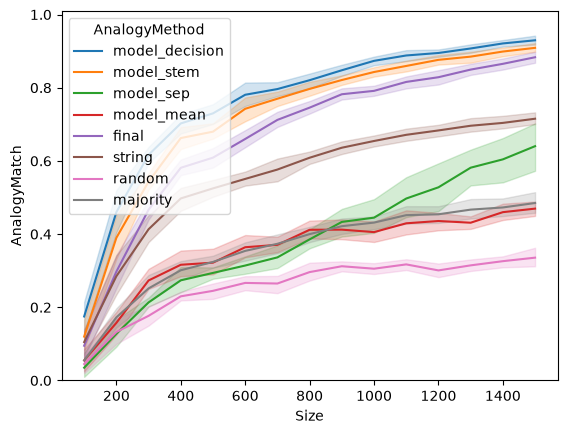

In [30]:
ax = sns.lineplot(res.loc[res['Type'] == 'all'], x='Size', y='AnalogyMatch', hue='AnalogyMethod')
ax.set_ylim(0.0, 1.01)
plt.show()

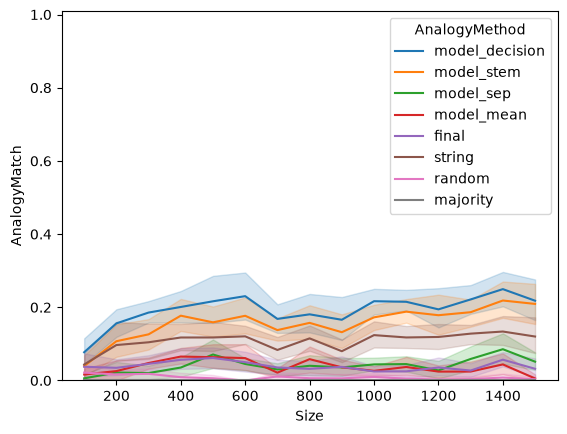

In [37]:
ax = sns.lineplot(res.loc[res['Type'] == 'irregular'], x='Size', y='AnalogyMatch', hue='AnalogyMethod')
ax.set_ylim(0.0, 1.01)
plt.show()